# Employee Salary Prediction - Advanced Regression Pipeline

## 1. Business Problem & Project Overview
This project aims to develop a robust, end-to-end Machine Learning pipeline to predict employee salaries based on market data, experience levels, and company characteristics.

**Objective:** Build a scalable, production-ready regression system capable of identifying salary patterns and providing accurate estimations to support HR compensation proposals.

**Key Workflow Steps:**
1. Data Acquisition & Initial Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (Custom Transformers)
4. Preprocessing Pipelines
5. Model Benchmarking (Dynamic Selection)
6. Automatic Hyperparameter Tuning using Optuna
7. Final Model Evaluation & Diagnostics
8. Error Analysis by Segment & Feature Importance

## 2. Environment Setup & Imports
Importing all required libraries, setting seeds for reproducibility, and configuring standard plotting styles.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn import set_config

# Models (Top 5 Regression Algorithms)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb

# Tuning
import optuna

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

# Configuration
warnings.filterwarnings('ignore')
set_config(transform_output="pandas")
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Data Acquisition & Initial Cleaning
Loading the dataset and applying basic sanity checks.

In [2]:
# Loads the dataset from the specified path, performs initial cleaning, and removes duplicates.
def load_and_clean_data(filepath: Path) -> pd.DataFrame:
    print(f"Loading data from: {filepath.relative_to(PROJECT_ROOT)}")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: File {filepath} not found. Please ensure the dataset is in the correct directory.")
        raise

    initial_shape = df.shape
    df = df.drop_duplicates()
    final_shape = df.shape

    print(f"Initial shape: {initial_shape}")
    print(f"Duplicates dropped: {initial_shape[0] - final_shape[0]}")
    print(f"Missing values: {df.isna().sum().sum()}")
    print(f"Final shape: {final_shape}\n")

    return df

# Relative path so the notebook runs from the project root or from the notebooks/ folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'job_salary_prediction_dataset.csv'
df = load_and_clean_data(DATA_PATH)

TARGET_COL = 'salary'

display(df.head())

Loading data from: data\job_salary_prediction_dataset.csv


Initial shape: (250000, 10)
Duplicates dropped: 0
Missing values: 0
Final shape: (250000, 10)



,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 4. Exploratory Data Analysis (EDA)

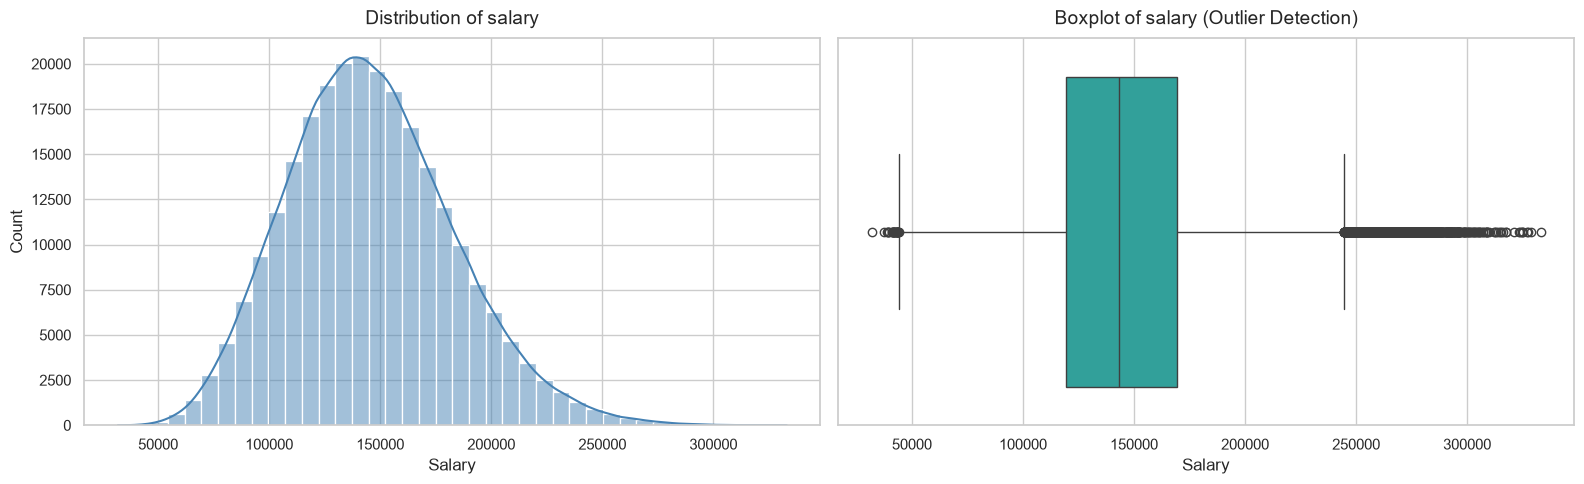

,count,mean,std,min,25%,50%,75%,max
salary,250000.0,145718.0,37408.0,31867.0,119358.0,143453.0,169492.0,333046.0


Skewness: 0.379


In [3]:
def plot_target_distribution(dataframe: pd.DataFrame, target: str):
    """Plots the distribution and boxplot for the continuous target variable."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(dataframe[target], kde=True, ax=axes[0], color='steelblue', bins=40)
    axes[0].set_title(f'Distribution of {target}', fontsize=14, pad=10)
    axes[0].set_xlabel('Salary')
    
    sns.boxplot(x=dataframe[target], ax=axes[1], color='lightseagreen')
    axes[1].set_title(f'Boxplot of {target} (Outlier Detection)', fontsize=14, pad=10)
    axes[1].set_xlabel('Salary')
    
    plt.tight_layout()
    plt.show()

plot_target_distribution(df, TARGET_COL)

display(df[TARGET_COL].describe().to_frame().T.round(0))
print(f"Skewness: {df[TARGET_COL].skew():.3f}")

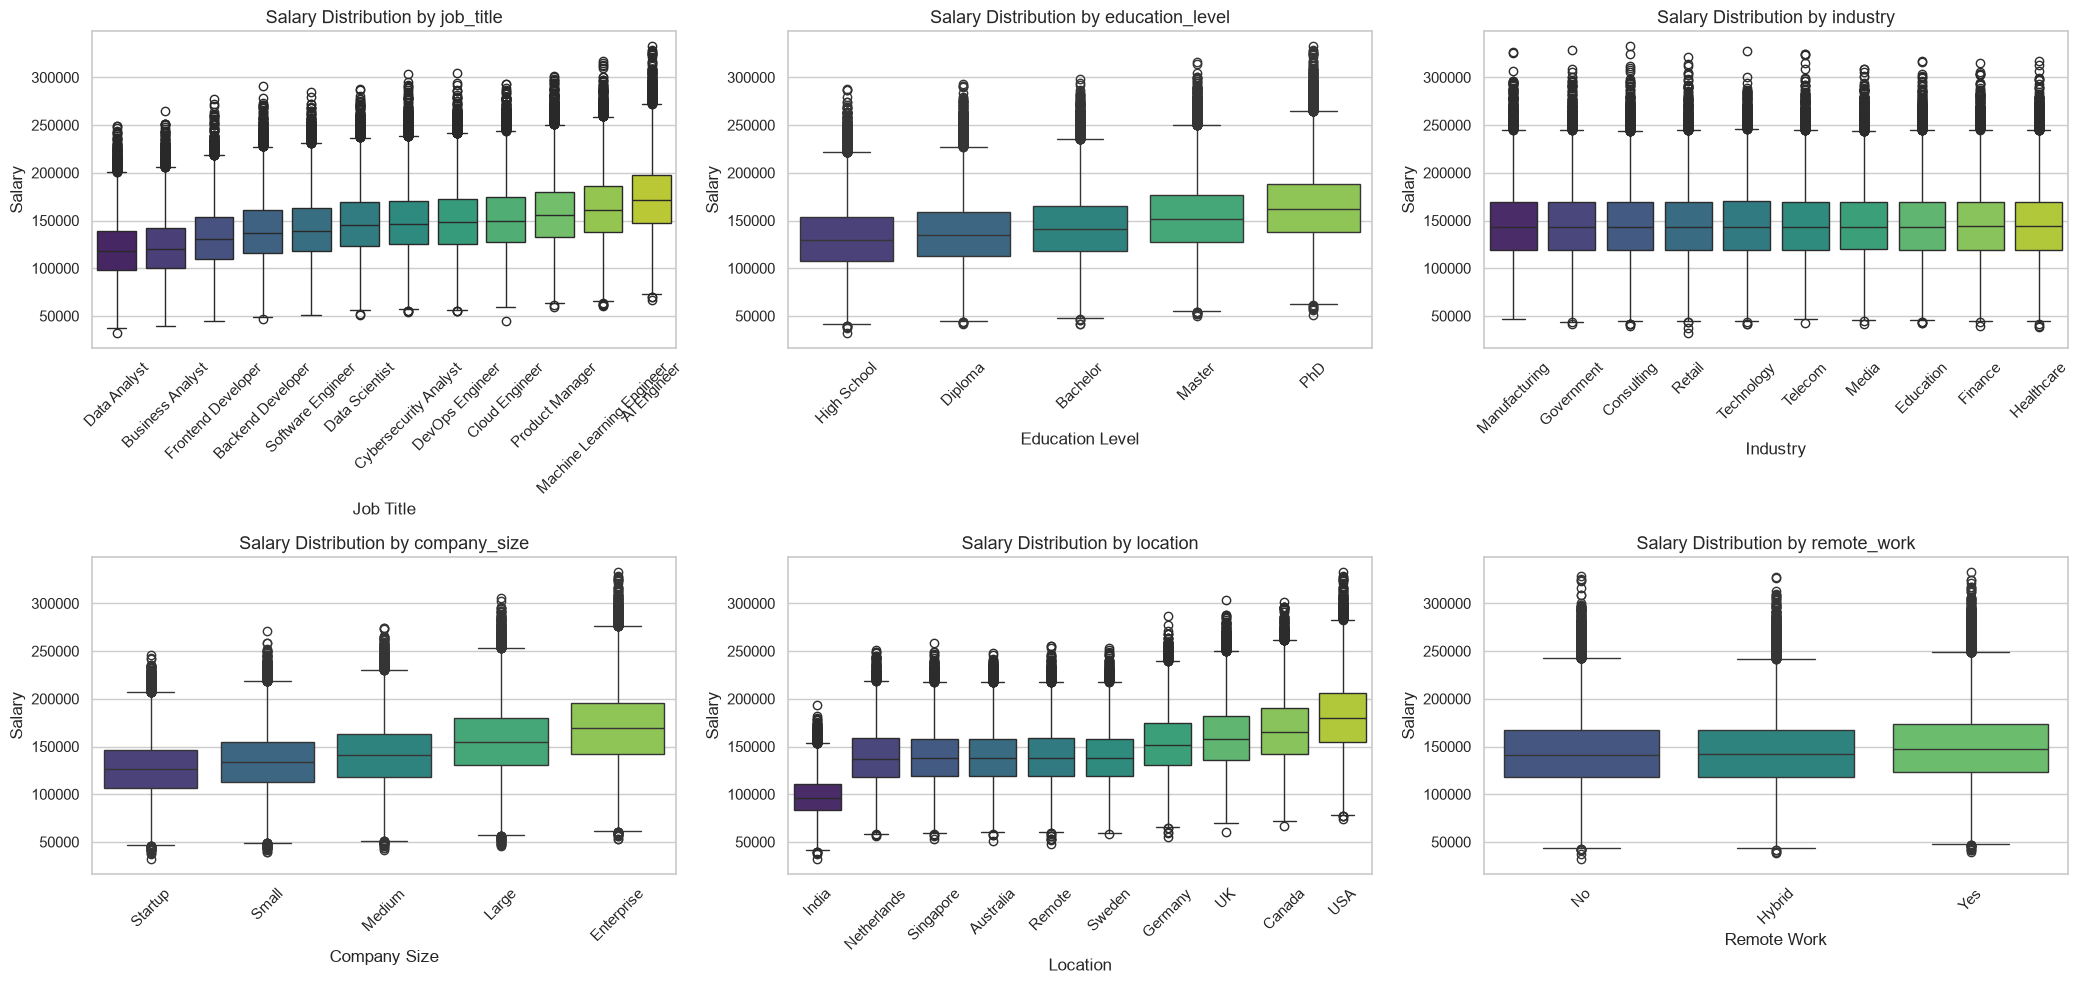

In [4]:
# Ordinal categories are displayed in their natural order; nominal ones by median salary.
CATEGORY_ORDER = {
    'education_level': ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'],
    'company_size': ['Startup', 'Small', 'Medium', 'Large', 'Enterprise'],
    'remote_work': ['No', 'Hybrid', 'Yes'],
}

def plot_categorical_relationships(dataframe: pd.DataFrame, target: str, n_cols: int = 3):
    """Analyzes the relationship between every categorical feature and the target."""
    cat_cols = dataframe.drop(columns=[target]).select_dtypes(exclude='number').columns.tolist()
    if not cat_cols:
        return

    n_rows = int(np.ceil(len(cat_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, cat_col in zip(axes, cat_cols):
        order = CATEGORY_ORDER.get(
            cat_col,
            dataframe.groupby(cat_col)[target].median().sort_values().index.tolist()
        )
        sns.boxplot(data=dataframe, x=cat_col, y=target, order=order, hue=cat_col,
                    hue_order=order, palette="viridis", legend=False, ax=ax)
        ax.set_title(f'Salary Distribution by {cat_col}', fontsize=13)
        ax.set_xlabel(cat_col.replace('_', ' ').title())
        ax.set_ylabel('Salary')
        ax.tick_params(axis='x', rotation=45)

    for ax in axes[len(cat_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

plot_categorical_relationships(df, TARGET_COL)

## 5. Train-Validation-Test Split

In [5]:
# Create Train, Validation, and Test Sets
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 1. Split into temporary train and final test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# 2. Split temporary train into actual train and validation (80/20 of the temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (160000, 9)
Validation set shape: (40000, 9)
Testing set shape: (50000, 9)


## 6. Custom Feature Engineering Classes
Implementing domain-specific transformations, outlier clipping, and rare category grouping.

`education_level` and `company_size` are ordinal: besides their one-hot encoding, `FeatureEngineer` adds a numeric rank so the models (especially the linear one) can exploit the natural ordering.

In [6]:
# Custom transformer to apply domain-specific feature engineering (ordinal ranks).
class FeatureEngineer(BaseEstimator, TransformerMixin):
    ORDINAL_MAPS = {
        'education_level': {'High School': 0, 'Diploma': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4},
        'company_size': {'Startup': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4},
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        for col, mapping in self.ORDINAL_MAPS.items():
            if col in X_out.columns:
                # Unknown categories become NaN and are handled by the numeric imputer
                X_out[f'{col}_rank'] = X_out[col].map(mapping).astype(float)
        return X_out

# Clips numerical outliers based on the Interquartile Range (IQR) method.
class IQRTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, iqr_factor=1.5):
        self.iqr_factor = iqr_factor

    def fit(self, X, y=None):
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X_array, 25, axis=0)
        self.q3_ = np.nanpercentile(X_array, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.iqr_factor * self.iqr_
        self.upper_ = self.q3_ + self.iqr_factor * self.iqr_
        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float)
        clipped_array = np.clip(X_array, self.lower_, self.upper_)
        return pd.DataFrame(clipped_array, columns=X.columns, index=X.index)

# Groups infrequent categorical modalities into an 'Other' category.
class RareCategoryEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.columns_ = X_df.columns
        self.freqs_ = {col: X_df[col].value_counts(normalize=True) for col in self.columns_}
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        for col in self.columns_:
            rare = self.freqs_[col][self.freqs_[col] < self.threshold].index
            X_df[col] = X_df[col].replace(rare, "Other")
        return X_df

print("Custom classes defined successfully.")

Custom classes defined successfully.


## 7. Preprocessing Pipelines

In [7]:
# Feature types are detected AFTER feature engineering, so engineered columns are not dropped
X_train_fe = FeatureEngineer().fit_transform(X_train)
numeric_features = X_train_fe.select_dtypes(include='number').columns.tolist()
categorical_features = X_train_fe.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Define Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('iqr_clipper', IQRTransformer(iqr_factor=1.5)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare_encoder', RareCategoryEncoder(threshold=0.05)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

data_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Builds a full pipeline with a fresh (cloned) preprocessor so fitted pipelines never share state.
def build_pipeline(model) -> Pipeline:
    return Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('data_prep', clone(data_pipeline)),
        ('regressor', model)
    ])

print("\nPipelines configured successfully.")

Numeric features (5): ['experience_years', 'skills_count', 'certifications', 'education_level_rank', 'company_size_rank']
Categorical features (6): ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

Pipelines configured successfully.


## 8. Model Benchmarking (Dynamic Evaluation)
Evaluating the top 5 regression models on the validation set to dynamically identify the best baseline algorithm. A naive `DummyRegressor` (always predicts the mean training salary) is included as the floor every model must beat.

Evaluating Baseline (Mean)...


Evaluating Ridge Regression...


Evaluating Random Forest...


Evaluating Gradient Boosting...


Evaluating XGBoost...


Evaluating LightGBM...


,Model,Validation_R2,Validation_RMSE,Validation_MAE
5,LightGBM,0.9785,5459.7542,4349.6414
4,XGBoost,0.9782,5494.3100,4375.0298
2,Random Forest,0.9707,6377.7346,5053.9887
1,Ridge Regression,0.9630,7163.1248,5485.9515
3,Gradient Boosting,0.9546,7938.3574,6231.0747
0,Baseline (Mean),-0.0000,37242.7502,29687.1490


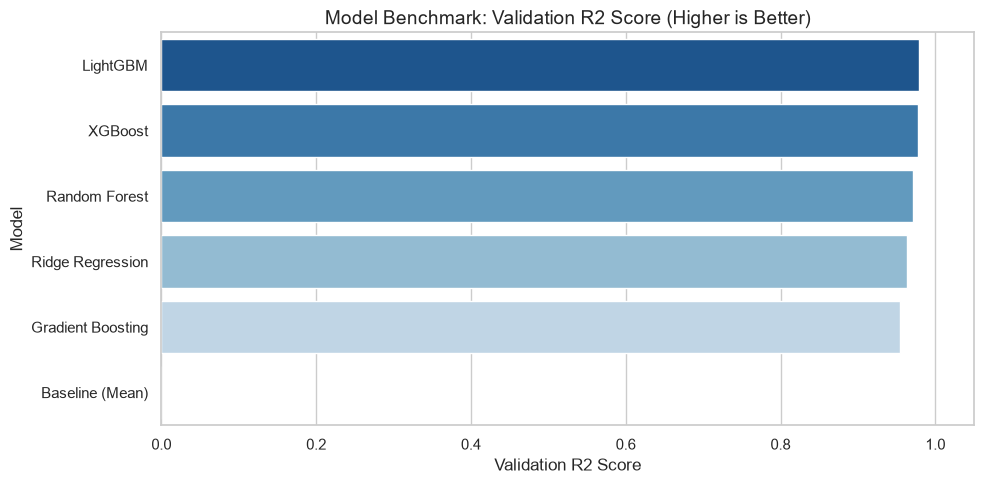

In [8]:
# Define the benchmark models (Top 5 Regression Models)
benchmark_models = {
    'Baseline (Mean)': DummyRegressor(strategy='mean'),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror'),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
}

# Trains multiple models on the training set and evaluates them on the validation set.
def run_benchmark(models_dict, X_train_split, y_train_split, X_val_split, y_val_split):
    results = []
    
    for name, model in models_dict.items():
        print(f"Evaluating {name}...")
        # Create full pipeline for the current model
        model_pipeline = build_pipeline(model)
        
        # Fit strictly on the training set
        model_pipeline.fit(X_train_split, y_train_split)
        
        # Evaluate on the validation set
        y_val_pred = model_pipeline.predict(X_val_split)
        score_r2 = r2_score(y_val_split, y_val_pred)
        score_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
        score_mae = mean_absolute_error(y_val_split, y_val_pred)
        
        results.append({
            'Model': name,
            'Validation_R2': score_r2,
            'Validation_RMSE': score_rmse,
            'Validation_MAE': score_mae
        })
        
    results_df = pd.DataFrame(results).sort_values(by='Validation_R2', ascending=False)
    return results_df

# Execute Benchmark
benchmark_results = run_benchmark(benchmark_models, X_train, y_train, X_val, y_val)
display(benchmark_results.round(4))

# Plot Benchmark Results
plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_results, x='Validation_R2', y='Model', hue='Model', palette='Blues_r', legend=False)
plt.title("Model Benchmark: Validation R2 Score (Higher is Better)", fontsize=14)
plt.xlabel("Validation R2 Score")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 9. Automatic Hyperparameter Tuning using Optuna
Dynamically injecting the best baseline model into an Optuna study to find the most optimal hyperparameters for production.

In [9]:
# Dynamically identify the best model from the benchmarking step
best_model_name = benchmark_results.query("Model != 'Baseline (Mean)'").iloc[0]['Model']
print(f"Best model automatically selected for tuning: {best_model_name}")

# Returns the hyperparameter search space specific to the selected model.
def get_optuna_params(trial, model_name):
    if model_name == 'Ridge Regression':
        return {
            'alpha': trial.suggest_float('alpha', 0.01, 10.0, log=True)
        }
    elif model_name == 'Random Forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
        }

    elif model_name == 'Gradient Boosting':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }

    elif model_name == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0)
        }

    elif model_name == 'LightGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }
    
    return {}

# Merges fixed base parameters with dynamic Optuna parameters and instantiates the selected model.
def get_model_instance(model_name, dynamic_params):
    base_params = {}

    if model_name == 'Ridge Regression':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return Ridge(**base_params)
    elif model_name == 'Random Forest':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return RandomForestRegressor(**base_params)
    elif model_name == 'Gradient Boosting':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return GradientBoostingRegressor(**base_params)
    elif model_name == 'XGBoost':
        base_params = {'random_state': RANDOM_STATE, 'objective': 'reg:squarederror'}
        base_params.update(dynamic_params)
        return xgb.XGBRegressor(**base_params)
    elif model_name == 'LightGBM':
        base_params = {'random_state': RANDOM_STATE, 'verbose': -1}
        base_params.update(dynamic_params)
        return lgb.LGBMRegressor(**base_params)
    raise ValueError(f"Model {model_name} is not supported.")

def objective(trial, model_name, X_train_split, y_train_split, X_val_split, y_val_split):
    # 1. Fetch parameters dynamically
    params = get_optuna_params(trial, model_name)
    model_instance = get_model_instance(model_name, params)
    
    # 2. Build Pipeline
    full_pipeline = build_pipeline(model_instance)
    
    # 3. Fit strictly on the training set
    full_pipeline.fit(X_train_split, y_train_split)
    
    # 4. Evaluate explicitly on the validation set
    y_val_pred = full_pipeline.predict(X_val_split)
    
    # We maximize R2 Score
    score = r2_score(y_val_split, y_val_pred)
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

print(f"Starting Optuna Tuning for {best_model_name}...")
study.optimize(lambda trial: objective(trial, best_model_name, X_train, y_train, X_val, y_val), n_trials=10, show_progress_bar=False)

print("Optimization Completed.")
print(f"Best Validation R2-Score: {study.best_value:.4f}")
baseline_val_r2 = benchmark_results.set_index('Model').loc[best_model_name, 'Validation_R2']
print(f"Untuned {best_model_name} Validation R2-Score: {baseline_val_r2:.4f}")
print(f"Best Parameters: {study.best_params}")

Best model automatically selected for tuning: LightGBM
Starting Optuna Tuning for LightGBM...


Optimization Completed.
Best Validation R2-Score: 0.9803
Untuned LightGBM Validation R2-Score: 0.9785
Best Parameters: {'n_estimators': 521, 'learning_rate': 0.08341106432362087, 'num_leaves': 22, 'max_depth': 10}


## 10. Final Model Evaluation & Diagnostics
Training the model with the best parameters combining train and validation sets, and evaluating it securely on the unseen test set.

In [10]:
# Combine Train and Validation sets for final training
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Build final model instance with the discovered best parameters
final_model_instance = get_model_instance(best_model_name, study.best_params)
final_pipeline = build_pipeline(final_model_instance)
final_pipeline.fit(X_full_train, y_full_train)

# Predictions strictly on the Test Set
y_pred = final_pipeline.predict(X_test)

# Naive reference on the same test set
y_pred_naive = DummyRegressor(strategy='mean').fit(X_full_train, y_full_train).predict(X_test)

def regression_metrics(y_true, y_hat) -> dict:
    rel_error = np.abs(y_true - y_hat) / y_true
    return {
        'MAE': mean_absolute_error(y_true, y_hat),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_hat)),
        'R2': r2_score(y_true, y_hat),
        'MAPE_%': 100 * mean_absolute_percentage_error(y_true, y_hat),
        'Within_10%_of_actual': 100 * np.mean(rel_error <= 0.10),
    }

test_metrics = pd.DataFrame({
    f'Tuned {best_model_name}': regression_metrics(y_test, y_pred),
    'Baseline (Mean)': regression_metrics(y_test, y_pred_naive),
}).T

print("Final Test Set Metrics:")
display(test_metrics.round(4))

Final Test Set Metrics:


,MAE,RMSE,R2,MAPE_%,Within_10%_of_actual
Tuned LightGBM,4128.6747,5175.9793,0.9807,3.0432,98.088
Baseline (Mean),29694.6403,37280.8806,-0.0000,22.6605,30.568


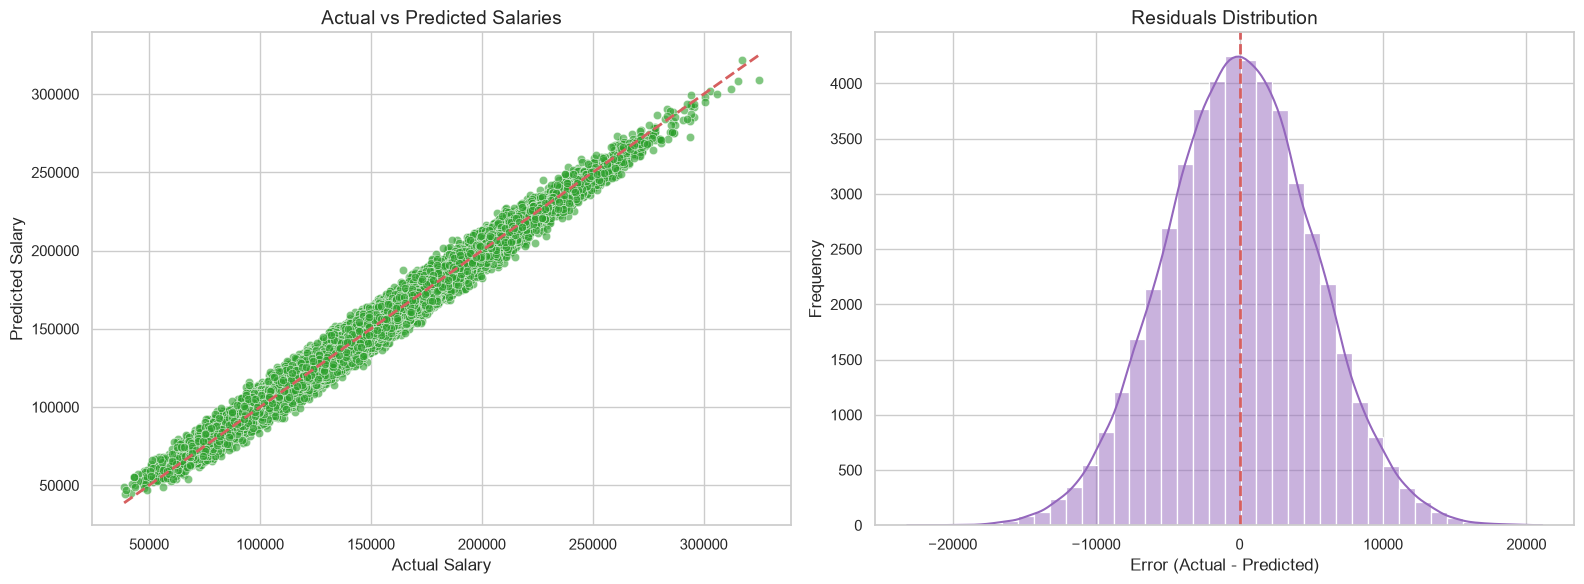

In [11]:
def plot_regression_diagnostics(y_true: pd.Series, y_pred: np.ndarray):
    """Plots Actual vs Predicted and Residuals Distribution."""
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Actual vs Predicted
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, color='#2ca02c', ax=axes[0])
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_title('Actual vs Predicted Salaries', fontsize=14)
    axes[0].set_xlabel('Actual Salary')
    axes[0].set_ylabel('Predicted Salary')
    
    # Residuals Distribution
    sns.histplot(residuals, kde=True, ax=axes[1], color='#9467bd', bins=40)
    axes[1].axvline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Residuals Distribution', fontsize=14)
    axes[1].set_xlabel('Error (Actual - Predicted)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

plot_regression_diagnostics(y_test, y_pred)

## 11. Error Analysis by Segment
A single global metric can hide where the model is weaker. The same absolute error weighs more on a lower salary, so errors are broken down by location, job title, company size and salary quintile, in absolute (MAE) and relative (MAPE) terms.

In [12]:
error_df = X_test[['location', 'job_title', 'company_size']].copy()
error_df['actual'] = y_test
error_df['abs_error'] = np.abs(y_test - y_pred)
error_df['pct_error'] = 100 * error_df['abs_error'] / y_test
error_df['salary_quintile'] = pd.qcut(y_test, 5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])

def error_by(segment: str) -> pd.DataFrame:
    return (error_df.groupby(segment, observed=True)
            .agg(n=('actual', 'size'), median_salary=('actual', 'median'),
                 MAE=('abs_error', 'mean'), MAPE_pct=('pct_error', 'mean'))
            .sort_values('MAPE_pct')
            .round(1))

segment_tables = {seg: error_by(seg) for seg in ['location', 'job_title', 'company_size', 'salary_quintile']}
for seg, table in segment_tables.items():
    print(f"\nError by {seg}:")
    display(table)


Error by location:


,n,median_salary,MAE,MAPE_pct
location,,,,
USA,5012,179928.0,4249.9,2.4
Canada,5012,164945.5,4163.6,2.6
UK,4986,158110.5,4153.1,2.7
Germany,5055,152062.0,4067.0,2.8
Sweden,5042,138556.0,4031.7,3.0
Remote,5048,137302.0,4070.5,3.1
Netherlands,4912,137412.0,4117.4,3.1
Australia,5002,137457.5,4113.2,3.1
Singapore,4944,137705.5,4183.4,3.1



Error by job_title:


,n,median_salary,MAE,MAPE_pct
job_title,,,,
AI Engineer,4216,170992.5,4230.5,2.6
Machine Learning Engineer,4087,159940.0,4041.3,2.6
Product Manager,4225,156285.0,4049.7,2.7
Cloud Engineer,4188,149780.0,4059.0,2.8
DevOps Engineer,4206,148718.5,4116.3,2.9
Cybersecurity Analyst,4228,147482.0,4095.8,2.9
Data Scientist,4093,144745.0,4153.9,3.0
Software Engineer,4298,139425.0,4125.8,3.1
Backend Developer,4186,135937.5,4161.2,3.2



Error by company_size:


,n,median_salary,MAE,MAPE_pct
company_size,,,,
Enterprise,9943,168866.0,4158.3,2.6
Large,10028,155248.0,4156.3,2.8
Medium,9994,141149.5,4119.8,3.1
Small,10151,134568.0,4137.4,3.3
Startup,9884,126351.0,4070.8,3.4



Error by salary_quintile:


,n,median_salary,MAE,MAPE_pct
salary_quintile,,,,
Q5 (highest),10000,194876.0,4209.4,2.1
Q4,10000,163541.5,4067.1,2.5
Q3,10000,143547.0,4073.3,2.8
Q2,9999,124694.0,4135.9,3.3
Q1 (lowest),10001,99128.0,4157.6,4.4


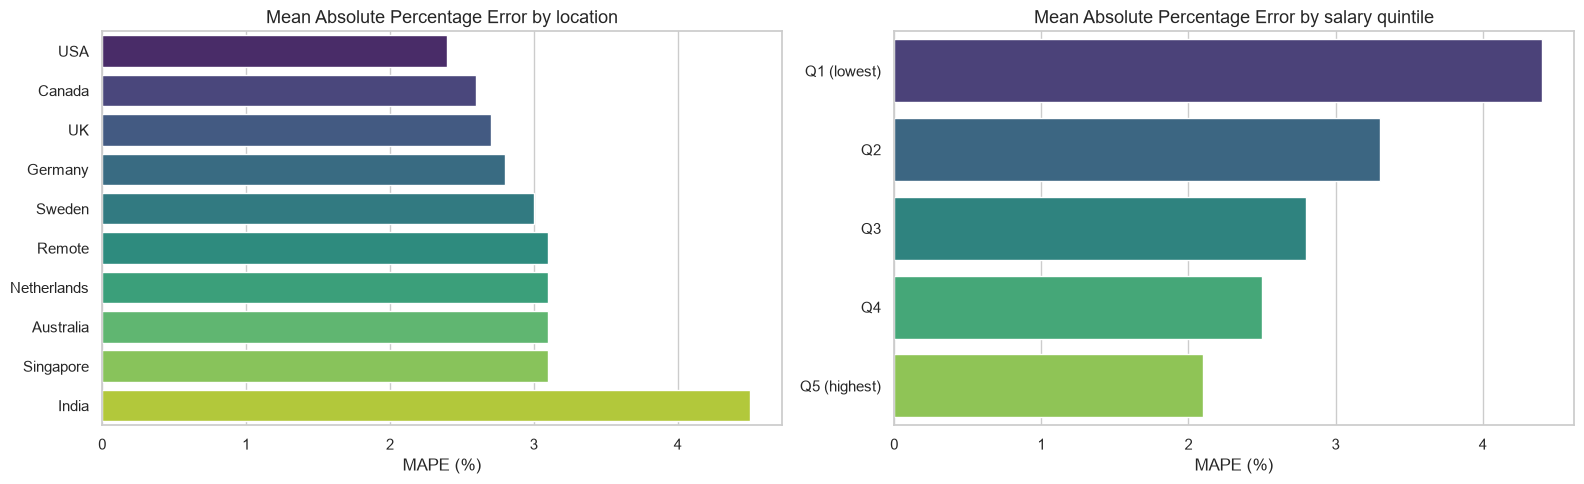

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, seg in zip(axes, ['location', 'salary_quintile']):
    table = segment_tables[seg].reset_index()
    sns.barplot(data=table, x='MAPE_pct', y=seg, hue=seg, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Mean Absolute Percentage Error by {seg.replace("_", " ")}', fontsize=13)
    ax.set_xlabel('MAPE (%)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 12. What Drives the Predictions (Permutation Importance)
Permutation importance is computed on the **original** features through the full pipeline, so each one-hot encoded feature is measured as a single business variable. It answers: *how much worse (in MAE, dollars) does the model get if this information is scrambled?*

,feature,MAE_increase,std
0,location,18776.8,156.3
1,experience_years,15239.3,132.2
2,company_size,13645.5,80.9
3,job_title,13488.6,56.4
4,education_level,9602.7,86.9
5,skills_count,2718.2,25.1
6,certifications,1081.8,28.3
7,remote_work,917.8,13.7
8,industry,2.1,0.9


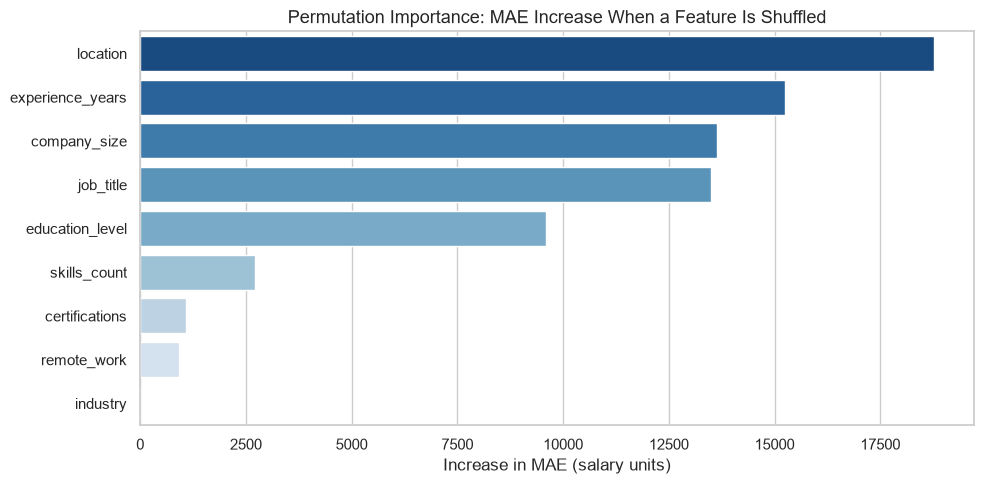

In [14]:
sample_idx = X_test.sample(n=10_000, random_state=RANDOM_STATE).index
perm = permutation_importance(
    final_pipeline, X_test.loc[sample_idx], y_test.loc[sample_idx],
    scoring='neg_mean_absolute_error', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = (pd.DataFrame({'feature': X_test.columns,
                               'MAE_increase': perm.importances_mean,
                               'std': perm.importances_std})
                 .sort_values('MAE_increase', ascending=False)
                 .reset_index(drop=True))
display(importance_df.round(1))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='MAE_increase', y='feature', hue='feature', palette='Blues_r', legend=False)
plt.title('Permutation Importance: MAE Increase When a Feature Is Shuffled', fontsize=13)
plt.xlabel('Increase in MAE (salary units)')
plt.ylabel('')
plt.tight_layout()
plt.show()